In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
df = pd.read_csv('/content/AirQualityUCI.csv',sep=';')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [ ]:
df.shape

(9471, 17)

In [ ]:
df.replace(-200, np.nan, inplace=True)
df.isna().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),114
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


In [ ]:
def analyze_column(column_name):

  print("\n=====================")
  print("Analysis of:", column_name)
  print("=======================\n")

  print("Summary Statistics:")
  print(df[column_name].describe())

  print("\nKey Measures:")
  print("Mean:", df[column_name].mean())
  print("Standard deviation:", df[column_name].std())
  print("Skewness:", df[column_name].skew())

  plt.figure()
  plt.hist(df[column_name].dropna(), bins=20)
  plt.title("Histogram of" + column_name)
  plt.xlabel(column_name)
  plt.ylabel("Frequency")
  plt.show()

  plt.figure()
  plt.boxplot(df[column_name].dropna())
  plt.title("Boxplot of" + column_name)
  plt.show()



Analysis of: CO(GT)

Summary Statistics:
count    9357.000000
mean      -34.207524
std        77.657170
min      -200.000000
25%         0.600000
50%         1.500000
75%         2.600000
max        11.900000
Name: CO(GT), dtype: float64

Key Measures:
Mean: -34.207523778989
Standard deviation: 77.65717034682939
Skewness: -1.666179501747376


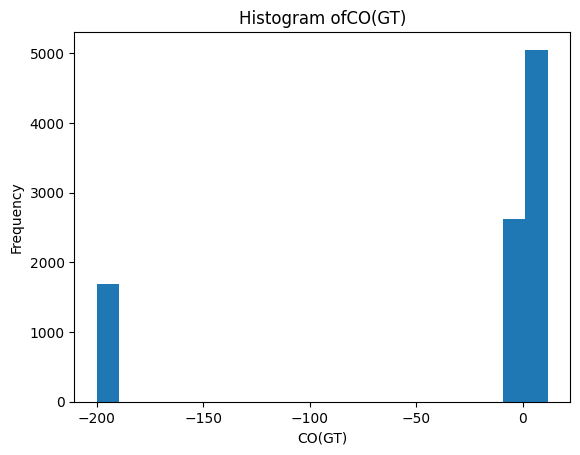

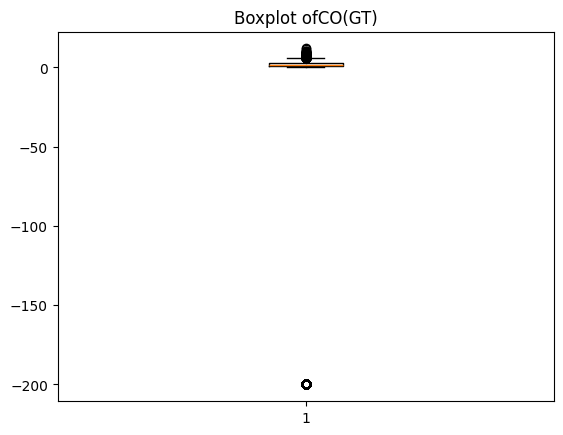


Analysis of: RH

Summary Statistics:
count    9357.000000
mean       39.485380
std        51.216145
min      -200.000000
25%        34.100000
50%        48.600000
75%        61.900000
max        88.700000
Name: RH, dtype: float64

Key Measures:
Mean: 39.48537992946458
Standard deviation: 51.2161449717661
Skewness: -3.932407357473095


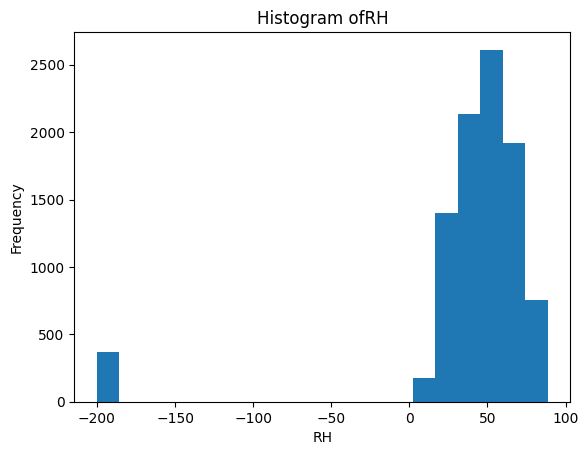

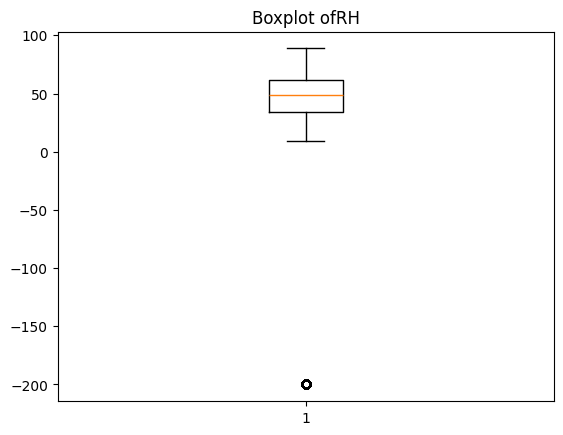


Analysis of: T

Summary Statistics:
count    9357.000000
mean        9.778305
std        43.203623
min      -200.000000
25%        10.900000
50%        17.200000
75%        24.100000
max        44.600000
Name: T, dtype: float64

Key Measures:
Mean: 9.778305012290264
Standard deviation: 43.20362306262309
Skewness: -4.445467032868759


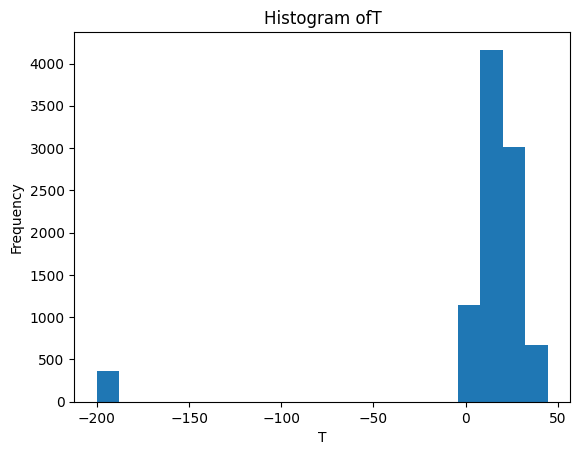

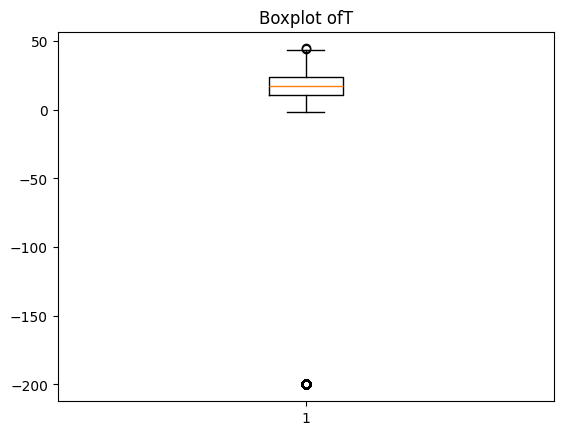


Analysis of: AH

Summary Statistics:
count    9357.000000
mean       -6.837604
std        38.976670
min      -200.000000
25%         0.692300
50%         0.976800
75%         1.296200
max         2.231000
Name: AH, dtype: float64

Key Measures:
Mean: -6.837603644330447
Standard deviation: 38.97667016632429
Skewness: -4.754570289874502


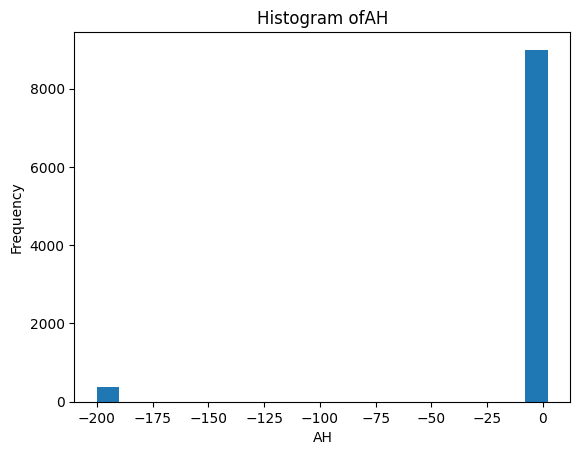

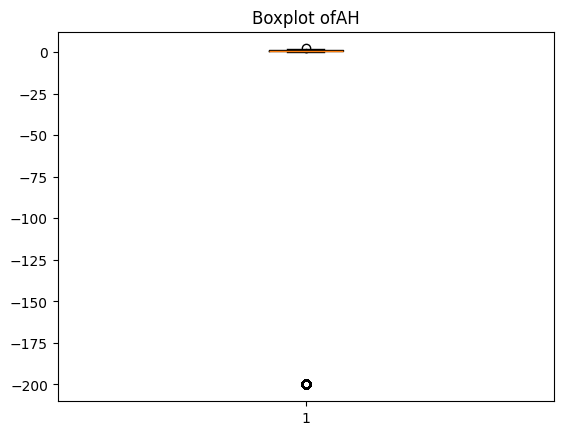

In [ ]:
# Convert problematic columns to numeric
for col in ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']:
    # Check if the column is of object type and contains commas before converting
    # This prevents errors if a column is already numeric or doesn't have commas
    if df[col].dtype == 'object' and df[col].astype(str).str.contains(',').any():
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

analyze_column('CO(GT)')
analyze_column('RH')
analyze_column('T')
analyze_column('AH')


Analysis of: NOx(GT)

Summary Statistics:
count    7718.000000
mean      246.896735
std       212.979168
min         2.000000
25%        98.000000
50%       180.000000
75%       326.000000
max      1479.000000
Name: NOx(GT), dtype: float64

Key Measures:
Mean: 246.8967349054159
Standard deviation: 212.97916810358612
Skewness: 1.7157807992815408


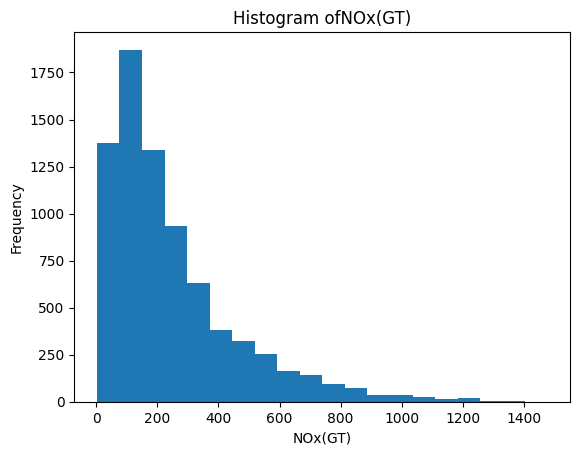

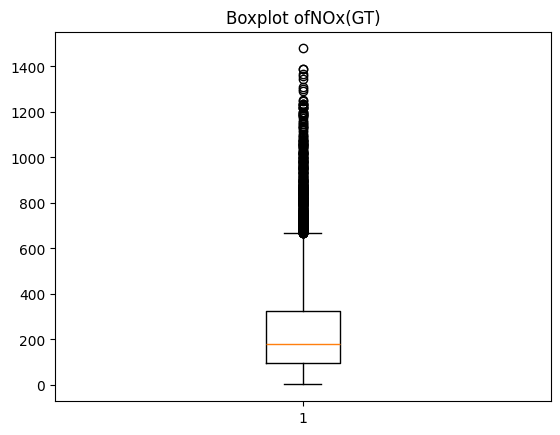


Analysis of: NO2(GT)

Summary Statistics:
count    7715.000000
mean      113.091251
std        48.370108
min         2.000000
25%        78.000000
50%       109.000000
75%       142.000000
max       340.000000
Name: NO2(GT), dtype: float64

Key Measures:
Mean: 113.09125081011017
Standard deviation: 48.370107782225396
Skewness: 0.6217143134373714


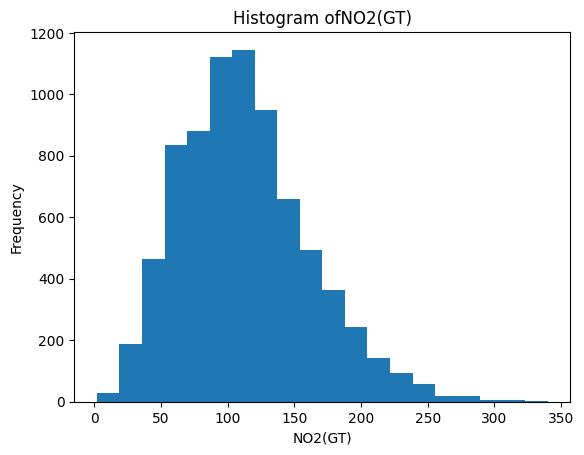

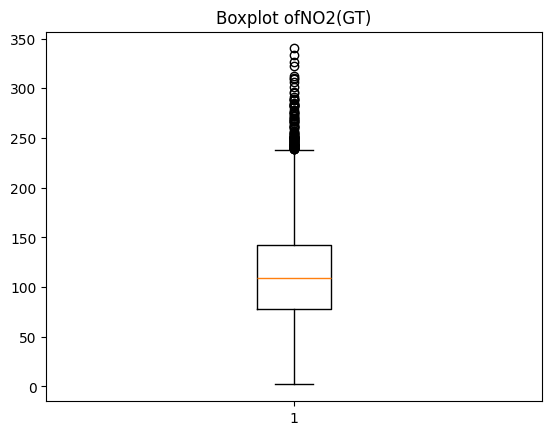

In [ ]:
analyze_column('NOx(GT)')
analyze_column('NO2(GT)')